<a href="https://colab.research.google.com/github/DhamodharThyiagarajan/Dsa_py/blob/main/DSA_Prep_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSA Preparation Notebook


**Topics covered:**
1. Arrays & Strings
2. Searching Algorithms
3. Sorting Algorithms
4. Multiple Pointers
5. Frequency Count
6. Sliding Window
7. Recursion Fundamentals (+ Backtracking)

> Tip: Run each code cell to see it work on the sample input. Then try modifying inputs to test edge cases yourself — that's how mastery happens.


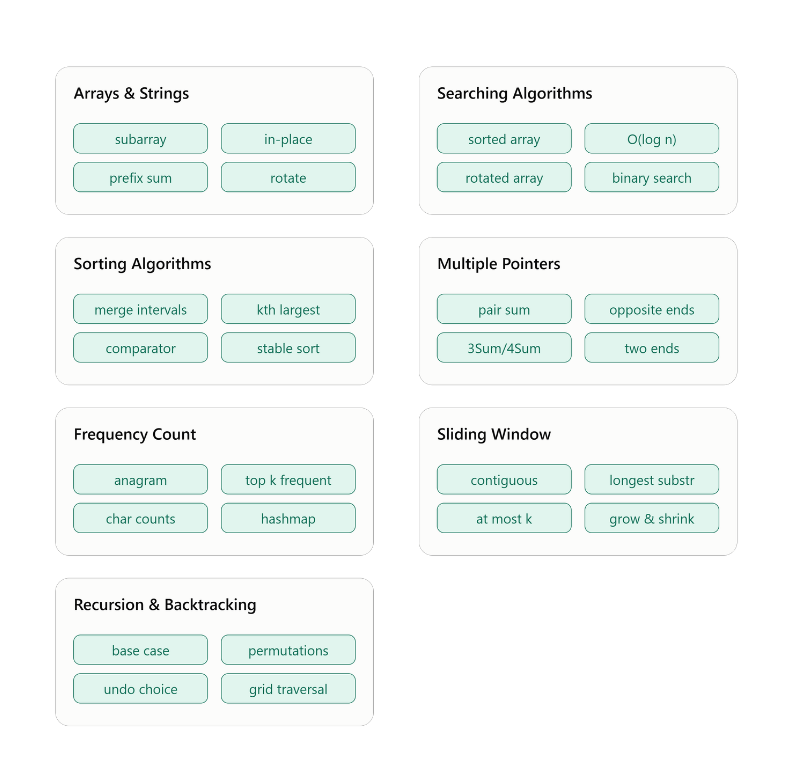

---
## 1️⃣ Arrays & Strings

**Need of this topic:**
Arrays and strings are the foundation of almost every DSA problem. Nearly every interview round starts here because they test whether you can reason about indices, in-place modification, and linear scans before moving to harder structures. Mastering array/string manipulation builds the intuition needed for two pointers, sliding window, and DP later.

**🔑 Cue words to recognize this pattern:**
- "contiguous subarray", "in-place", "without extra space"
- "prefix sum" / "running total"
- "rotate the array", "rearrange elements"
- "find maximum/minimum sum"


### 🟡 Medium 1: Maximum Subarray Sum (Kadane's Algorithm)

**Problem:** Given an integer array `nums`, find the contiguous subarray with the largest sum and return its sum.

**Sample Input:** `nums = [-2,1,-3,4,-1,2,1,-5,4]`
**Sample Output:** `6`  (subarray `[4,-1,2,1]`)

**Suggestion:** Track a running sum `cur`. At each step decide: "should I extend the previous subarray, or start fresh from here?" That decision (`max(n, cur+n)`) IS Kadane's algorithm. This same "extend or restart" idea reappears in many DP problems.


In [ ]:
def max_subarray(nums):
    max_sum = cur = nums[0]
    for n in nums[1:]:
        cur = max(n, cur + n)      # extend or restart
        max_sum = max(max_sum, cur)
    return max_sum

# Sample run
print(max_subarray([-2,1,-3,4,-1,2,1,-5,4]))  # Expected: 6

# Time Complexity: O(n)  |  Space Complexity: O(1)


### 🟡 Medium 2: Product of Array Except Self

**Problem:** Given `nums`, return an array `res` such that `res[i]` equals the product of all elements except `nums[i]`, **without using division** and in O(n) time.

**Sample Input:** `nums = [1,2,3,4]`
**Sample Output:** `[24,12,8,6]`

**Suggestion:** Compute prefix products from the left and suffix products from the right in two passes, multiplying them together. This "prefix + suffix" trick is reusable anywhere you need "everything except me".


In [ ]:
def product_except_self(nums):
    n = len(nums)
    res = [1] * n
    left = 1
    for i in range(n):
        res[i] = left
        left *= nums[i]
    right = 1
    for i in range(n - 1, -1, -1):
        res[i] *= right
        right *= nums[i]
    return res

# Sample run
print(product_except_self([1,2,3,4]))  # Expected: [24, 12, 8, 6]

# Time Complexity: O(n)  |  Space Complexity: O(1) extra (excluding output array)


### 🔴 Hard 1: Trapping Rain Water

**Problem:** Given `n` non-negative integers representing an elevation map, compute how much water it can trap after raining.

**Sample Input:** `height = [0,1,0,2,1,0,1,3,2,1,2,1]`
**Sample Output:** `6`

**Suggestion:** Water trapped at index `i` = `min(max_left, max_right) - height[i]`. Instead of precomputing both arrays (O(n) space), use two pointers from both ends and always move the side with the smaller max — that side's water level is already determined.


In [ ]:
def trap(height):
    n = len(height)
    if n == 0:
        return 0
    left, right = 0, n - 1
    left_max, right_max = height[left], height[right]
    water = 0
    while left < right:
        if left_max < right_max:
            left += 1
            left_max = max(left_max, height[left])
            water += left_max - height[left]
        else:
            right -= 1
            right_max = max(right_max, height[right])
            water += right_max - height[right]
    return water

# Sample run
print(trap([0,1,0,2,1,0,1,3,2,1,2,1]))  # Expected: 6

# Time Complexity: O(n)  |  Space Complexity: O(1)


### 🔴 Hard 2: First Missing Positive

**Problem:** Given an unsorted integer array `nums`, find the smallest missing positive integer, in O(n) time and O(1) extra space.

**Sample Input:** `nums = [3,4,-1,1]`
**Sample Output:** `2`

**Suggestion:** The answer must lie in `[1, n+1]`. Use the array itself as a hash table: place each value `v` (1..n) at index `v-1` by swapping. Then scan for the first index where `nums[i] != i+1`.


In [ ]:
def first_missing_positive(nums):
    n = len(nums)
    for i in range(n):
        while 1 <= nums[i] <= n and nums[nums[i] - 1] != nums[i]:
            target = nums[i] - 1
            nums[i], nums[target] = nums[target], nums[i]
    for i in range(n):
        if nums[i] != i + 1:
            return i + 1
    return n + 1

# Sample run
print(first_missing_positive([3,4,-1,1]))  # Expected: 2

# Time Complexity: O(n)  |  Space Complexity: O(1)


---
## 2️⃣ Searching Algorithms

**Need of this topic:**
Whenever data is sorted (or has a monotonic property), binary search shrinks an O(n) scan to O(log n). Recognizing "hidden" binary search opportunities — like searching for an *answer* rather than an *index* — is a huge lever in interviews and competitive programming.

**🔑 Cue words to recognize this pattern:**
- "sorted array", "rotated sorted array"
- "find target in O(log n)"
- "minimum/maximum value satisfying a condition" (binary search on the answer)
- "first/last occurrence"


### 🟡 Medium 1: Search in Rotated Sorted Array

**Problem:** A sorted array is rotated at an unknown pivot. Given `target`, return its index or -1 in O(log n).

**Sample Input:** `nums = [4,5,6,7,0,1,2], target = 0`
**Sample Output:** `4`

**Suggestion:** At each `mid`, one half (`lo..mid` or `mid..hi`) is always properly sorted. Check which half is sorted, then check if `target` lies in that sorted half's range to decide direction.


In [ ]:
def search_rotated(nums, target):
    lo, hi = 0, len(nums) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if nums[mid] == target:
            return mid
        if nums[lo] <= nums[mid]:          # left half sorted
            if nums[lo] <= target < nums[mid]:
                hi = mid - 1
            else:
                lo = mid + 1
        else:                              # right half sorted
            if nums[mid] < target <= nums[hi]:
                lo = mid + 1
            else:
                hi = mid - 1
    return -1

# Sample run
print(search_rotated([4,5,6,7,0,1,2], 0))  # Expected: 4

# Time Complexity: O(log n)  |  Space Complexity: O(1)


### 🟡 Medium 2: Find First and Last Position of Element in Sorted Array

**Problem:** Given a sorted array `nums` and `target`, find the starting and ending index of `target`. Return `[-1,-1]` if not found.

**Sample Input:** `nums = [5,7,7,8,8,10], target = 8`
**Sample Output:** `[3,4]`

**Suggestion:** Run binary search twice — once biased to find the leftmost occurrence, once biased to find the rightmost. Python's `bisect_left`/`bisect_right` do exactly this.


In [ ]:
import bisect

def search_range(nums, target):
    l = bisect.bisect_left(nums, target)
    if l == len(nums) or nums[l] != target:
        return [-1, -1]
    r = bisect.bisect_right(nums, target) - 1
    return [l, r]

# Sample run
print(search_range([5,7,7,8,8,10], 8))  # Expected: [3, 4]

# Time Complexity: O(log n)  |  Space Complexity: O(1)


### 🔴 Hard 1: Median of Two Sorted Arrays

**Problem:** Given two sorted arrays `A` and `B` of size `m` and `n`, return the median of the combined array in O(log(min(m,n))) time.

**Sample Input:** `A = [1,3], B = [2]`
**Sample Output:** `2.0`

**Suggestion:** Binary search on the smaller array to find a partition index `i` (and derive `j` from it) such that everything on the left of both partitions is ≤ everything on the right. Don't merge the arrays — that's the O(m+n) approach; the interviewer wants the log version.


In [ ]:
def find_median_sorted_arrays(A, B):
    if len(A) > len(B):
        A, B = B, A
    m, n = len(A), len(B)
    lo, hi = 0, m
    half = (m + n + 1) // 2
    while lo <= hi:
        i = (lo + hi) // 2
        j = half - i
        A_left  = A[i - 1] if i > 0 else float('-inf')
        A_right = A[i]     if i < m else float('inf')
        B_left  = B[j - 1] if j > 0 else float('-inf')
        B_right = B[j]     if j < n else float('inf')
        if A_left <= B_right and B_left <= A_right:
            if (m + n) % 2 == 1:
                return float(max(A_left, B_left))
            return (max(A_left, B_left) + min(A_right, B_right)) / 2
        elif A_left > B_right:
            hi = i - 1
        else:
            lo = i + 1

# Sample run
print(find_median_sorted_arrays([1,3], [2]))  # Expected: 2.0

# Time Complexity: O(log(min(m, n)))  |  Space Complexity: O(1)


### 🔴 Hard 2: Split Array Largest Sum

**Problem:** Given an array `nums` and an integer `k`, split it into `k` non-empty contiguous subarrays to **minimize the largest sum** among them.

**Sample Input:** `nums = [7,2,5,10,8], k = 2`
**Sample Output:** `18`  (split as `[7,2,5]` and `[10,8]`)

**Suggestion:** This is "binary search on the answer": search over possible values of the "largest sum" (between `max(nums)` and `sum(nums)`), and greedily check with a helper "can we split into ≤ k parts using this sum as a cap?"


In [ ]:
def split_array(nums, k):
    def feasible(cap):
        count, total = 1, 0
        for n in nums:
            if total + n > cap:
                count += 1
                total = n
                if count > k:
                    return False
            else:
                total += n
        return True

    lo, hi = max(nums), sum(nums)
    while lo < hi:
        mid = (lo + hi) // 2
        if feasible(mid):
            hi = mid
        else:
            lo = mid + 1
    return lo

# Sample run
print(split_array([7,2,5,10,8], 2))  # Expected: 18

# Time Complexity: O(n * log(sum - max))  |  Space Complexity: O(1)


---
## 3️⃣ Sorting Algorithms

**Need of this topic:**
Sorting is rarely the final answer by itself — it's usually the *enabler* that turns an O(n²) brute force into an O(n log n) solution by exposing structure (adjacent elements become comparable, intervals become mergeable, order statistics become accessible via a heap).

**🔑 Cue words to recognize this pattern:**
- "merge overlapping intervals"
- "kth largest/smallest"
- "custom comparator / sort by criteria"
- "count of inversions / smaller elements after"


### 🟡 Medium 1: Merge Intervals

**Problem:** Given a collection of intervals, merge all overlapping intervals.

**Sample Input:** `intervals = [[1,3],[2,6],[8,10],[15,18]]`
**Sample Output:** `[[1,6],[8,10],[15,18]]`

**Suggestion:** Sort intervals by start time first. Then a single linear pass suffices: if the current interval's start ≤ the last merged interval's end, merge them; otherwise start a new group.


In [ ]:
def merge_intervals(intervals):
    intervals.sort(key=lambda x: x[0])
    res = [intervals[0]]
    for s, e in intervals[1:]:
        if s <= res[-1][1]:
            res[-1][1] = max(res[-1][1], e)
        else:
            res.append([s, e])
    return res

# Sample run
print(merge_intervals([[1,3],[2,6],[8,10],[15,18]]))
# Expected: [[1, 6], [8, 10], [15, 18]]

# Time Complexity: O(n log n)  |  Space Complexity: O(n)


### 🟡 Medium 2: Kth Largest Element in an Array

**Problem:** Find the `k`th largest element in an unsorted array (not the kth distinct element).

**Sample Input:** `nums = [3,2,1,5,6,4], k = 2`
**Sample Output:** `5`

**Suggestion:** Full sort works (O(n log n)) but a min-heap of size `k` (or Python's `heapq.nlargest`) is the standard "textbook efficient" answer, especially useful when data streams in.


In [ ]:
import heapq

def kth_largest(nums, k):
    return heapq.nlargest(k, nums)[-1]

# Sample run
print(kth_largest([3,2,1,5,6,4], 2))  # Expected: 5

# Time Complexity: O(n log k)  |  Space Complexity: O(k)


### 🔴 Hard 1: Count of Smaller Numbers After Self

**Problem:** Given an array `nums`, return `counts` where `counts[i]` is the number of elements to the right of `nums[i]` that are smaller than it.

**Sample Input:** `nums = [5,2,6,1]`
**Sample Output:** `[2,1,1,0]`

**Suggestion:** This is a disguised "count inversions" problem. Compress values to ranks, then use a **Binary Indexed Tree (Fenwick Tree)** while scanning right-to-left: query how many smaller ranks have been inserted so far, then insert the current rank.


In [ ]:
def count_smaller(nums):
    n = len(nums)
    res = [0] * n
    sorted_unique = sorted(set(nums))
    rank = {v: i for i, v in enumerate(sorted_unique)}
    bit = [0] * (len(sorted_unique) + 1)

    def update(i):
        i += 1
        while i < len(bit):
            bit[i] += 1
            i += i & (-i)

    def query(i):
        i += 1
        s = 0
        while i > 0:
            s += bit[i]
            i -= i & (-i)
        return s

    for i in range(n - 1, -1, -1):
        r = rank[nums[i]]
        res[i] = query(r - 1) if r > 0 else 0
        update(r)
    return res

# Sample run
print(count_smaller([5,2,6,1]))  # Expected: [2, 1, 1, 0]

# Time Complexity: O(n log n)  |  Space Complexity: O(n)


### 🔴 Hard 2: Merge k Sorted Lists

**Problem:** You are given `k` sorted lists. Merge them into one sorted list.

**Sample Input:** `lists = [[1,4,5],[1,3,4],[2,6]]`
**Sample Output:** `[1,1,2,3,4,4,5,6]`

**Suggestion:** Don't concatenate + sort (that ignores the "already sorted" structure). Use a min-heap holding one "current" element per list; repeatedly pop the smallest and push that list's next element.


In [ ]:
import heapq

def merge_k_lists(lists):
    heap = []
    for i, l in enumerate(lists):
        if l:
            heap.append((l[0], i, 0))
    heapq.heapify(heap)
    res = []
    while heap:
        val, i, j = heapq.heappop(heap)
        res.append(val)
        if j + 1 < len(lists[i]):
            heapq.heappush(heap, (lists[i][j + 1], i, j + 1))
    return res

# Sample run
print(merge_k_lists([[1,4,5],[1,3,4],[2,6]]))
# Expected: [1, 1, 2, 3, 4, 4, 5, 6]

# Time Complexity: O(N log k)  where N = total elements, k = number of lists
# Space Complexity: O(k)


---
## 4️⃣ Multiple Pointers

**Need of this topic:**
Two/multiple pointer techniques turn many O(n²) brute-force nested loops into O(n) or O(n log n) by exploiting sorted order or symmetric structure, moving pointers from both ends (or at different speeds) instead of re-scanning.

**🔑 Cue words to recognize this pattern:**
- "sorted array, pair/triplet with sum ="
- "opposite ends", "meet in the middle"
- "palindrome check / expand around center"
- "in-place partition, no extra space"


### 🟡 Medium 1: Two Sum II - Input Array Is Sorted

**Problem:** Given a 1-indexed sorted array, find two numbers that add up to `target`. Return their 1-based indices.

**Sample Input:** `numbers = [2,7,11,15], target = 9`
**Sample Output:** `[1,2]`

**Suggestion:** Because the array is sorted, use two pointers at both ends. If the sum is too big, move the right pointer left; if too small, move the left pointer right.


In [ ]:
def two_sum_sorted(numbers, target):
    l, r = 0, len(numbers) - 1
    while l < r:
        s = numbers[l] + numbers[r]
        if s == target:
            return [l + 1, r + 1]
        elif s < target:
            l += 1
        else:
            r -= 1
    return []

# Sample run
print(two_sum_sorted([2,7,11,15], 9))  # Expected: [1, 2]

# Time Complexity: O(n)  |  Space Complexity: O(1)


### 🟡 Medium 2: 3Sum

**Problem:** Given an array `nums`, find all unique triplets `[a,b,c]` such that `a+b+c = 0`.

**Sample Input:** `nums = [-1,0,1,2,-1,-4]`
**Sample Output:** `[[-1,-1,2],[-1,0,1]]`

**Suggestion:** Sort first. Fix one element `nums[i]`, then use the two-pointer technique on the remaining subarray to find pairs summing to `-nums[i]`. Skip duplicate values at every level to avoid duplicate triplets.


In [ ]:
def three_sum(nums):
    nums.sort()
    n = len(nums)
    res = []
    for i in range(n - 2):
        if i > 0 and nums[i] == nums[i - 1]:
            continue
        l, r = i + 1, n - 1
        while l < r:
            s = nums[i] + nums[l] + nums[r]
            if s == 0:
                res.append([nums[i], nums[l], nums[r]])
                while l < r and nums[l] == nums[l + 1]:
                    l += 1
                while l < r and nums[r] == nums[r - 1]:
                    r -= 1
                l += 1
                r -= 1
            elif s < 0:
                l += 1
            else:
                r -= 1
    return res

# Sample run
print(three_sum([-1,0,1,2,-1,-4]))
# Expected: [[-1, -1, 2], [-1, 0, 1]]

# Time Complexity: O(n^2)  |  Space Complexity: O(1) extra (excluding output)


### 🔴 Hard 1: 4Sum

**Problem:** Given an array `nums` and integer `target`, find all unique quadruplets `[a,b,c,d]` that sum to `target`.

**Sample Input:** `nums = [1,0,-1,0,-2,2], target = 0`
**Sample Output:** `[[-2,-1,1,2],[-2,0,0,2],[-1,0,0,1]]`

**Suggestion:** Generalize 3Sum by adding one more fixed outer loop, then two-pointer on the rest. Careful, disciplined duplicate-skipping at every nested level is what makes this "hard" in practice.


In [ ]:
def four_sum(nums, target):
    nums.sort()
    n = len(nums)
    res = []
    for i in range(n - 3):
        if i > 0 and nums[i] == nums[i - 1]:
            continue
        for j in range(i + 1, n - 2):
            if j > i + 1 and nums[j] == nums[j - 1]:
                continue
            l, r = j + 1, n - 1
            while l < r:
                s = nums[i] + nums[j] + nums[l] + nums[r]
                if s == target:
                    res.append([nums[i], nums[j], nums[l], nums[r]])
                    while l < r and nums[l] == nums[l + 1]:
                        l += 1
                    while l < r and nums[r] == nums[r - 1]:
                        r -= 1
                    l += 1
                    r -= 1
                elif s < target:
                    l += 1
                else:
                    r -= 1
    return res

# Sample run
print(four_sum([1,0,-1,0,-2,2], 0))
# Expected: [[-2, -1, 1, 2], [-2, 0, 0, 2], [-1, 0, 0, 1]]

# Time Complexity: O(n^3)  |  Space Complexity: O(1) extra (excluding output)


### 🔴 Hard 2: Longest Palindromic Substring

**Problem:** Given a string `s`, return the longest palindromic substring.

**Sample Input:** `s = "babad"`
**Sample Output:** `"bab"` (or `"aba"` — both valid)

**Suggestion:** For every index (and every gap between indices, for even-length palindromes), expand two pointers outward while characters match. This "expand around center" approach uses O(n) centers × O(n) expansion = O(n²), much simpler to implement than Manacher's O(n) algorithm.


In [1]:
def longest_palindrome(s):
    if not s:
        return ""
    start, end = 0, 0

    def expand(l, r):
        while l >= 0 and r < len(s) and s[l] == s[r]:
            l -= 1
            r += 1
        return l + 1, r - 1

    for i in range(len(s)):
        l1, r1 = expand(i, i)        # odd length
        if r1 - l1 > end - start:
            start, end = l1, r1
        l2, r2 = expand(i, i + 1)    # even length
        if r2 - l2 > end - start:
            start, end = l2, r2
    return s[start:end + 1]

# Sample run
print(longest_palindrome("babad"))  # Expected: "bab" (or "aba")

# Time Complexity: O(n^2)  |  Space Complexity: O(1)


bab


---
## 5️⃣ Frequency Count

**Need of this topic:**
Whenever a problem is about "how many times" something occurs, or comparing the composition of two collections (anagrams, majority elements, character distributions), a hashmap-based frequency count converts an O(n²) comparison problem into O(n).

**🔑 Cue words to recognize this pattern:**
- "anagram", "permutation of a string"
- "frequency", "occurs more than ⌊n/k⌋ times"
- "top k frequent", "most/least common"
- "character count match"


### 🟡 Medium 1: Group Anagrams

**Problem:** Given an array of strings, group the anagrams together.

**Sample Input:** `strs = ["eat","tea","tan","ate","nat","bat"]`
**Sample Output:** `[["eat","tea","ate"],["tan","nat"],["bat"]]`

**Suggestion:** Anagrams share the same "signature" — either their sorted characters or their frequency-count tuple. Use that signature as a hashmap key and bucket the strings.


In [ ]:
from collections import defaultdict

def group_anagrams(strs):
    groups = defaultdict(list)
    for s in strs:
        key = tuple(sorted(s))
        groups[key].append(s)
    return list(groups.values())

# Sample run
print(group_anagrams(["eat","tea","tan","ate","nat","bat"]))
# Expected (order may vary): [['eat','tea','ate'], ['tan','nat'], ['bat']]

# Time Complexity: O(n * k log k)  where k = max string length
# Space Complexity: O(n * k)


### 🟡 Medium 2: Top K Frequent Elements

**Problem:** Given an integer array `nums` and integer `k`, return the `k` most frequent elements.

**Sample Input:** `nums = [1,1,1,2,2,3], k = 2`
**Sample Output:** `[1,2]`

**Suggestion:** Count frequencies with a hashmap, then either use a heap of size k (`heapq.nlargest`) or bucket sort by frequency for a true O(n) solution.


In [ ]:
from collections import Counter
import heapq

def top_k_frequent(nums, k):
    count = Counter(nums)
    return heapq.nlargest(k, count.keys(), key=count.get)

# Sample run
print(top_k_frequent([1,1,1,2,2,3], 2))  # Expected: [1, 2]

# Time Complexity: O(n log k)  |  Space Complexity: O(n)


### 🔴 Hard 1: Substring with Concatenation of All Words

**Problem:** Given a string `s` and a list `words` (all of the same length), find all starting indices where a substring is exactly a concatenation of every word in `words`, each exactly once, in any order.

**Sample Input:** `s = "barfoothefoobarman", words = ["foo","bar"]`
**Sample Output:** `[0,9]`

**Suggestion:** Precompute a frequency map of `words`. Slide a window of length `len(words) * word_len` across `s`, and at each start, chop it into word-sized chunks and check the chunk frequencies match — bail out early on any mismatch.


In [ ]:
from collections import Counter

def find_substring(s, words):
    if not words:
        return []
    word_len = len(words[0])
    num_words = len(words)
    total_len = word_len * num_words
    word_count = Counter(words)
    res = []

    for i in range(len(s) - total_len + 1):
        seen = Counter()
        j = 0
        while j < num_words:
            word = s[i + j * word_len: i + (j + 1) * word_len]
            if word not in word_count:
                break
            seen[word] += 1
            if seen[word] > word_count[word]:
                break
            j += 1
        if j == num_words:
            res.append(i)
    return res

# Sample run
print(find_substring("barfoothefoobarman", ["foo","bar"]))  # Expected: [0, 9]

# Time Complexity: O(n * m)  where n = len(s), m = total_len (word_len*num_words)
# Space Complexity: O(m)


### 🔴 Hard 2: Minimum Window Substring

**Problem:** Given strings `s` and `t`, return the smallest substring of `s` that contains every character of `t` (including duplicates). Return `""` if impossible.

**Sample Input:** `s = "ADOBECODEBANC", t = "ABC"`
**Sample Output:** `"BANC"`

**Suggestion:** This combines frequency counting with sliding window. Track how many of `t`'s required characters are still "missing" in the current window. Expand right until nothing is missing, then greedily shrink from the left to find the minimal valid window.


In [ ]:
from collections import Counter

def min_window(s, t):
    if not s or not t:
        return ""
    need = Counter(t)
    missing = len(t)
    l = 0
    best_len, best_l, best_r = float('inf'), 0, 0

    for r, c in enumerate(s, 1):
        if need[c] > 0:
            missing -= 1
        need[c] -= 1
        if missing == 0:
            while l < r and need[s[l]] < 0:
                need[s[l]] += 1
                l += 1
            if r - l < best_len:
                best_len, best_l, best_r = r - l, l, r
            need[s[l]] += 1
            missing += 1
            l += 1

    return "" if best_len == float('inf') else s[best_l:best_r]

# Sample run
print(min_window("ADOBECODEBANC", "ABC"))  # Expected: "BANC"

# Time Complexity: O(n)  |  Space Complexity: O(k)  where k = distinct chars in t


---
## 6️⃣ Sliding Window

**Need of this topic:**
Sliding window is the go-to pattern whenever you need to examine every **contiguous** subarray/substring under some constraint (max sum, no repeats, at most k distinct, etc). It avoids recomputation by incrementally growing/shrinking a window instead of restarting from scratch, taking O(n²) brute force down to O(n).

**🔑 Cue words to recognize this pattern:**
- "contiguous subarray/substring"
- "longest/shortest ... satisfying a condition"
- "at most k", "exactly k distinct"
- "maximum/minimum sum of a fixed-size window"


### 🟡 Medium 1: Longest Substring Without Repeating Characters

**Problem:** Given a string `s`, find the length of the longest substring without repeating characters.

**Sample Input:** `s = "abcabcbb"`
**Sample Output:** `3`  (`"abc"`)

**Suggestion:** Keep a hashmap of `char -> last seen index`. Expand the right pointer; whenever you see a repeat *inside* the current window, jump the left pointer to just after that character's last occurrence.


In [ ]:
def length_of_longest_substring(s):
    seen = {}
    l = 0
    best = 0
    for r, c in enumerate(s):
        if c in seen and seen[c] >= l:
            l = seen[c] + 1
        seen[c] = r
        best = max(best, r - l + 1)
    return best

# Sample run
print(length_of_longest_substring("abcabcbb"))  # Expected: 3

# Time Complexity: O(n)  |  Space Complexity: O(min(n, alphabet size))


### 🟡 Medium 2: Maximum Sum Subarray of Size K

**Problem:** Given an array `nums` and integer `k`, find the maximum sum of any contiguous subarray of size exactly `k`.

**Sample Input:** `nums = [2,1,5,1,3,2], k = 3`
**Sample Output:** `9`  (`[5,1,3]`)

**Suggestion:** This is the simplest "fixed-size window" pattern: compute the first window's sum, then slide by subtracting the element leaving and adding the element entering — O(1) per step instead of recomputing the whole sum.


In [ ]:
def max_sum_subarray_k(nums, k):
    window_sum = sum(nums[:k])
    best = window_sum
    for i in range(k, len(nums)):
        window_sum += nums[i] - nums[i - k]
        best = max(best, window_sum)
    return best

# Sample run
print(max_sum_subarray_k([2,1,5,1,3,2], 3))  # Expected: 9

# Time Complexity: O(n)  |  Space Complexity: O(1)


### 🔴 Hard 1: Sliding Window Maximum

**Problem:** Given `nums` and window size `k`, return the maximum of each window as it slides from left to right.

**Sample Input:** `nums = [1,3,-1,-3,5,3,6,7], k = 3`
**Sample Output:** `[3,3,5,5,6,7]`

**Suggestion:** Use a **monotonic decreasing deque** storing indices. Before adding a new index, pop off all indices whose values are smaller (they can never be the max again). The front of the deque is always the current window's max; pop it if it slides out of range.


In [ ]:
from collections import deque

def max_sliding_window(nums, k):
    dq = deque()   # stores indices, values decreasing
    res = []
    for i, n in enumerate(nums):
        while dq and nums[dq[-1]] < n:
            dq.pop()
        dq.append(i)
        if dq[0] == i - k:
            dq.popleft()
        if i >= k - 1:
            res.append(nums[dq[0]])
    return res

# Sample run
print(max_sliding_window([1,3,-1,-3,5,3,6,7], 3))
# Expected: [3, 3, 5, 5, 6, 7]

# Time Complexity: O(n)  (each index pushed/popped at most once)
# Space Complexity: O(k)


### 🔴 Hard 2: Longest Substring with At Most K Distinct Characters

**Problem:** Given a string `s` and integer `k`, find the length of the longest substring with at most `k` distinct characters.

**Sample Input:** `s = "eceba", k = 2`
**Sample Output:** `3`  (`"ece"`)

**Suggestion:** Grow the window with a frequency map. Whenever the map has more than `k` distinct keys, shrink from the left (decrementing counts, deleting a key when its count hits 0) until the constraint is satisfied again.


In [ ]:
from collections import defaultdict

def length_of_longest_substring_k_distinct(s, k):
    count = defaultdict(int)
    l = 0
    best = 0
    for r, c in enumerate(s):
        count[c] += 1
        while len(count) > k:
            count[s[l]] -= 1
            if count[s[l]] == 0:
                del count[s[l]]
            l += 1
        best = max(best, r - l + 1)
    return best

# Sample run
print(length_of_longest_substring_k_distinct("eceba", 2))  # Expected: 3

# Time Complexity: O(n)  |  Space Complexity: O(k)


---
## 7️⃣ Recursion Fundamentals (+ Backtracking)

**Need of this topic:**
Recursion is how you express "solve a big problem in terms of smaller versions of itself." It underlies divide-and-conquer, tree/graph traversal, dynamic programming, and backtracking. If you can clearly identify the **base case** and the **recursive relation**, you can solve an enormous fraction of DSA problems.

**Backtracking** is a specialized recursion pattern: try a choice → recurse → **undo the choice** if it doesn't lead to a solution ("undo" is what separates backtracking from plain recursion). It's the standard tool for:
- **Combinatorics** — combinations, permutations, subsets
- **Grid traversals** — path finding, word search, maze solving

**🔑 Cue words to recognize this pattern:**
- "base case", "smaller subproblem", "divide and conquer"
- "all possible combinations/permutations/subsets"
- "generate all valid ...", "explore every path"
- "place N items on a board satisfying constraints" (N-Queens style)


### 🟡 Medium 1: Pow(x, n) — Fast Exponentiation

**Problem:** Implement `pow(x, n)`, i.e., compute `x` raised to the power `n`, in better than O(n) time.

**Sample Input:** `x = 2.0, n = 10`
**Sample Output:** `1024.0`

**Suggestion:** Base case: `n == 0 -> 1`. Recursive relation: `x^n = (x^(n/2))^2` if n even, else `(x^(n/2))^2 * x`. Halving `n` each call gives O(log n) instead of O(n) multiplications — a classic "divide and conquer via recursion" example.


In [ ]:
def my_pow(x, n):
    if n < 0:
        x = 1 / x
        n = -n

    def helper(x, n):
        if n == 0:
            return 1
        half = helper(x, n // 2)
        if n % 2 == 0:
            return half * half
        return half * half * x

    return helper(x, n)

# Sample run
print(my_pow(2.0, 10))  # Expected: 1024.0

# Time Complexity: O(log n)  |  Space Complexity: O(log n) (recursion stack)


### 🟡 Medium 2: Generate Parentheses

**Problem:** Given `n` pairs of parentheses, generate all combinations of well-formed parentheses.

**Sample Input:** `n = 3`
**Sample Output:** `["((()))","(()())","(())()","()(())","()()()"]`

**Suggestion:** Classic backtracking: at each step you may add `'('` if you haven't used all `n` yet, or add `')'` only if it wouldn't exceed the number of `'('` already placed. Base case: string length reaches `2n`.


In [ ]:
def generate_parenthesis(n):
    res = []

    def backtrack(s, open_c, close_c):
        if len(s) == 2 * n:
            res.append(s)
            return
        if open_c < n:
            backtrack(s + "(", open_c + 1, close_c)
        if close_c < open_c:
            backtrack(s + ")", open_c, close_c + 1)

    backtrack("", 0, 0)
    return res

# Sample run
print(generate_parenthesis(3))
# Expected: ['((()))', '(()())', '(())()', '()(())', '()()()']

# Time Complexity: O(4^n / sqrt(n))  (bounded by the nth Catalan number)
# Space Complexity: O(n) recursion depth (excluding output storage)


### 🔴 Hard 1: N-Queens

**Problem:** Place `n` queens on an `n x n` chessboard so that no two queens attack each other. Return all distinct board configurations.

**Sample Input:** `n = 4`
**Sample Output:** `2 solutions`:
`[".Q..","...Q","Q...","..Q."]` and `["..Q.","Q...","...Q",".Q.."]`

**Suggestion:** Place queens row by row (recursion depth = row number). Track occupied columns and both diagonals (`row-col` and `row+col` are constant along a diagonal) in sets for O(1) conflict checks. **Backtrack**: after exploring a placement, remove the queen and its diagonal/column markers before trying the next column.


In [ ]:
def solve_n_queens(n):
    res = []
    cols, diag1, diag2 = set(), set(), set()
    board = []

    def backtrack(row):
        if row == n:
            res.append(["".join(r) for r in board])
            return
        for col in range(n):
            if col in cols or (row - col) in diag1 or (row + col) in diag2:
                continue
            cols.add(col); diag1.add(row - col); diag2.add(row + col)
            board.append(['.'] * col + ['Q'] + ['.'] * (n - col - 1))

            backtrack(row + 1)

            board.pop()
            cols.remove(col); diag1.remove(row - col); diag2.remove(row + col)

    backtrack(0)
    return res

# Sample run
solutions = solve_n_queens(4)
print(f"Number of solutions: {len(solutions)}")
for sol in solutions:
    print(sol)
# Expected: 2 solutions

# Time Complexity: O(N!)  (bounded by permutations of column placements)
# Space Complexity: O(N^2) for the board + O(N) recursion depth


### 🔴 Hard 2: Word Search (Backtracking on a Grid)

**Problem:** Given a 2D `board` of characters and a `word`, return whether the word exists in the grid, formed by adjacent cells (horizontally/vertically), without reusing a cell.

**Sample Input:** `board = [["A","B","C","E"],["S","F","C","S"],["A","D","E","E"]], word = "ABCCED"`
**Sample Output:** `True`

**Suggestion:** This is the canonical **grid traversal backtracking** problem. At each cell, try all 4 directions; mark the cell visited before recursing and **restore it afterward** (the undo step) so other paths can reuse it. Prune early the moment a character doesn't match.


In [ ]:
def exist(board, word):
    rows, cols = len(board), len(board[0])

    def backtrack(r, c, i):
        if i == len(word):
            return True
        if r < 0 or r >= rows or c < 0 or c >= cols or board[r][c] != word[i]:
            return False
        temp = board[r][c]
        board[r][c] = '#'   # mark visited
        found = (backtrack(r + 1, c, i + 1) or backtrack(r - 1, c, i + 1) or
                 backtrack(r, c + 1, i + 1) or backtrack(r, c - 1, i + 1))
        board[r][c] = temp   # undo (backtrack)
        return found

    for r in range(rows):
        for c in range(cols):
            if backtrack(r, c, 0):
                return True
    return False

# Sample run
board = [["A","B","C","E"],["S","F","C","S"],["A","D","E","E"]]
print(exist(board, "ABCCED"))  # Expected: True

# Time Complexity: O(m * n * 4^L)  where L = len(word)
# Space Complexity: O(L) recursion depth
